# Phase 3 — Counterfactual Wind Series for January 2026

This notebook builds the **scenario-specific wind production series** that replace the flat `extra_wind_mw` placeholder in `Supply.py`.

**Output:** `data/wind_production_scenarios.csv` — 744 rows (31 days × 24 hours), one column per scenario, UTC-indexed.

**Prerequisite:** Run `ursula_wind_integration.ipynb` first to produce `data/entsoe_production_hourly.csv`.

---

## The core question

Scenarios S3 and S4 ask: *what would electricity prices in January 2026 have looked like if Estonia had more wind capacity?*

To answer this properly we need a **realistic, hour-by-hour wind production series** for the new farms — not a flat average MW addition. The reason matters: the January 2026 crisis had specific weather conditions. There were likely calm-wind hours when prices spiked and windier hours when prices were suppressed. A flat +323 MW assumption would erase this variability and overstate how much wind could have helped at the worst moments.

## Why weather-based estimation here, not ENTSOE?

For the **training period (2019–2025)**, we used actual ENTSOE production data — metered output from the existing grid.

For the **counterfactual scenarios**, those farms don't exist yet. There is no metered output to download. The only option is to estimate what they *would have* produced, using:
1. Actual January 2026 weather at the planned farm locations (ERA5 reanalysis via Open-Meteo)
2. A physical power curve model (Vestas V150-4.5 MW) that converts wind speed → power output

## Scenarios

| Scenario | New farms added | Added capacity | Total fleet |
|---|---|---|---|
| Baseline | — (existing farms only) | — | 694 MW |
| Scenario A | Lääneranna (area 2, 137 MW) + Pärnu+Tori Põlendmaa (86 MW) + Aidu (100 MW) | +323 MW | 1,017 MW |
| Scenario B | Adds 5 pipeline municipalities on top of Scenario A | +564 MW | 1,581 MW |

The baseline series represents what the *existing* 694 MW fleet would have produced — estimated the same way (weather × power curve × 694 MW), making it directly comparable to scenarios.


## Setup

Imports and the `get_weather_openmeteo` function, inlined here to avoid importing `torch` (which `helper_functions_GNN.py` pulls in at the module level). Open-Meteo uses **ERA5 reanalysis** — free, no API key, covers 1979 to present at hourly resolution, and critically returns **`wind_speed_100m`** which is near hub height (V150 hub = 105 m), making wind shear extrapolation from 10 m unnecessary.


In [45]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_weather_openmeteo(lat: float, lon: float, start: str, end: str) -> pd.DataFrame:
    """
    Fetch hourly ERA5 reanalysis from Open-Meteo archive (free, no API key).
    Returns UTC-indexed DataFrame: temperature (°C), wind_speed_10m, wind_speed_100m (m/s), pressure (hPa).
    """
    r = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude":        lat,
            "longitude":       lon,
            "start_date":      start[:10],
            "end_date":        end[:10],
            "hourly":          "temperature_2m,wind_speed_10m,wind_speed_100m,surface_pressure",
            "wind_speed_unit": "ms",
            "timezone":        "UTC",
        },
        timeout=60,
    )
    if r.status_code != 200:
        print(f"  ERROR {r.status_code}: {r.text[:200]}")
        return pd.DataFrame()

    data = r.json()
    df = pd.DataFrame({
        "timestamp":       pd.to_datetime(data["hourly"]["time"], utc=True),
        "temperature":     data["hourly"]["temperature_2m"],
        "wind_speed_10m":  data["hourly"]["wind_speed_10m"],
        "wind_speed_100m": data["hourly"]["wind_speed_100m"],
        "pressure":        data["hourly"]["surface_pressure"],
    }).set_index("timestamp").sort_index()

    df = df[~df.index.duplicated(keep="first")]
    print(f"  Fetched {len(df)} hours: {df.index[0].date()} → {df.index[-1].date()}")
    return df


JAN2026_START = "2026-01-01"
JAN2026_END   = "2026-01-31"
print("Setup complete.")


Setup complete.


## Power curve model — Vestas V150-4.5 MW

The Vestas V150-4.5 MW is the reference turbine for Estonia's newer onshore wind farms.

### Wind speed at hub height

The V150 hub is at **105 metres**. Open-Meteo (ERA5) provides `wind_speed_100m` — at 100 m, which is 5 m below hub height. The residual wind shear correction from 100 m to 105 m under the standard power law exponent (0.143) is:

$$v_{105} = v_{100} \times \left(\frac{105}{100}\right)^{0.143} \approx v_{100} \times 1.007$$

A 0.7% correction is negligible, so we use `wind_speed_100m` directly as hub-height wind speed. This is a major accuracy improvement over the old approach (extrapolating from 10 m introduces ~50% uncertainty and strong sensitivity to the shear exponent).

### Air density correction

Standard power curves assume **1.225 kg/m³** (sea level, 15 °C). Cold January air in Estonia is denser (~1.30–1.35 kg/m³):

$$\rho = \frac{p_{hPa} \times 100}{287.05 \times (T_C + 273.15)} \qquad P_{adj} = P_{nominal} \times \frac{\rho}{1.225}$$

### Capacity factor

Corrected output (kW) ÷ nameplate (4,500 kW) → capacity factor in [0, 1] × farm MW → hourly production in MW.


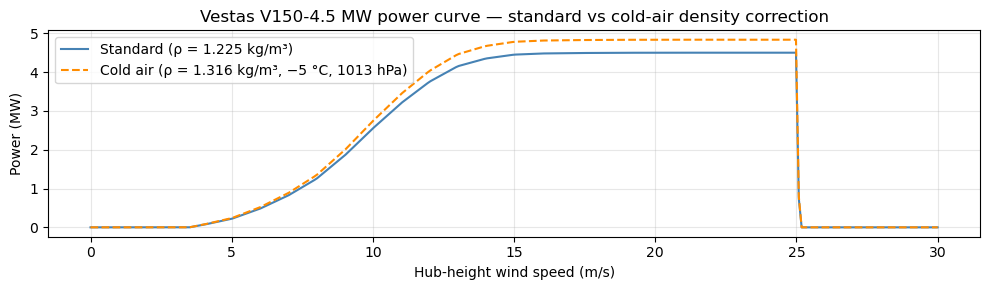

Power curve functions defined.


In [46]:
# Vestas V150-4.5 MW power curve
# Cut-in ~3.5 m/s, rated ~13 m/s, cut-out 25 m/s
POWER_CURVE_WS = np.array([0,1,2,3,3.5,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,25.1,50])
POWER_CURVE_KW = np.array([0,0,0,0,  0,66,220,480,820,1250,1850,2550,3200,3750,4150,4350,4450,4480,4490,4495,4498,4500,4500,4500,4500,4500,4500,0,0])

def air_density(temp_c, pressure_hpa):
    return (pressure_hpa * 100) / (287.05 * (temp_c + 273.15))

def power_curve_kw(v_hub, rho):
    p_nominal = np.interp(v_hub, POWER_CURVE_WS, POWER_CURVE_KW)
    return p_nominal * (rho / 1.225)

def turbine_cf(wind_speed_100m, temp_c, pressure_hpa):
    """Capacity factor in [0, 1]. Uses 100m wind speed as hub-height proxy (V150 hub = 105m)."""
    rho  = air_density(temp_c, pressure_hpa)
    p_kw = power_curve_kw(wind_speed_100m, rho)
    return np.clip(p_kw / 4500.0, 0, 1)

# Sanity plot
v_range  = np.linspace(0, 30, 300)
rho_std  = 1.225
rho_cold = air_density(-5, 1013)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(v_range, np.interp(v_range, POWER_CURVE_WS, POWER_CURVE_KW) / 1000,
        label="Standard (ρ = 1.225 kg/m³)", color="steelblue")
ax.plot(v_range, np.interp(v_range, POWER_CURVE_WS, POWER_CURVE_KW) * (rho_cold / 1.225) / 1000,
        label=f"Cold air (ρ = {rho_cold:.3f} kg/m³, −5 °C, 1013 hPa)",
        color="darkorange", linestyle="--")
ax.set_xlabel("Hub-height wind speed (m/s)")
ax.set_ylabel("Power (MW)")
ax.set_title("Vestas V150-4.5 MW power curve — standard vs cold-air density correction")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Power curve functions defined.")


## Wind farm locations

Coordinates are **geographic centroids computed from official Estonian planning GIS data** (Maa-amet / Estonian Land Board layers). The representative weather point is the centroid of each planning area polygon, which Open-Meteo then interpolates from the nearest ERA5 grid cell (~9 km resolution).

### Scenario A — currently valid plans (+323 MW)

Three plans with valid permit status as of January 2026:

- **Lääneranna rural municipality (area 2)** (137 MW) — partially established special plan, western coast near Lihula. Centroid: `tuul_ep_kehtestatud.geojson`.
- **Pärnu city + Tori rural municipality (Põlendmaa)** (86 MW) — established special plan, southwestern Pärnu. Centroid: `tuul_ep_kehtestatud.geojson`.
- **Aidu renewable energy park** (100 MW) — valid detailed plan (detailplaneering), northeastern Estonia near Kiviõli. Centroid: `tuulealad_DP.geojson` ("Aidu ja Aidu-Liiva").

Total: 137 + 86 + 100 = **323 MW**

### Scenario B — plans in the final stages (+564 MW on top of Scenario A)

Plans moving towards implementation that could add an estimated 564 MW. Two distinct planning-stage groups:

**Preliminary location decision and SEA report adopted** (more advanced):
- **Lääneranna** (150 MW) — northern Lääneranna planning areas (5, 5a, 3, 3b, 2a); a separate and larger plan from the Scenario A ala 2 site
- **Tori rural municipality** (100 MW) — northern Tori planning areas (1.1, 1.2, 1.3, 6.1); distinct from the Põlendmaa Scenario A plan
- **Lääne-Nigula** (100 MW) — coastal western Estonia, location selected

**Draft stage I and SEA published** (earlier stage):
- **Põhja-Pärnumaa** (100 MW) — northern Pärnumaa, pre-selection areas 3a, 3b, 9, 10
- **Lüganuse — Evecon OÜ and Enery Estonia OÜ wind farms** (114 MW) — northeastern Estonia, planning areas 1–3

Individual farm MW capacities are not yet public at this planning stage; the 564 MW total is distributed across the five groups proportionally by number of planning areas.

Source: `tuuleenergeetika_KOV_EP_alad.geojson`


In [47]:
# Scenario A: currently valid plans, centroids from official GIS data
# Sources: tuul_ep_kehtestatud.geojson (Lääneranna, Pärnu+Tori),
#          tuulealad_DP.geojson centroid (Aidu renewable energy park)
new_farms_A = [
    {"name": "Lääneranna (area 2)",      "lat": 58.4473, "lon": 23.7673, "capacity_mw": 137},
    {"name": "Pärnu+Tori (Põlendmaa)",   "lat": 58.3775, "lon": 24.7786, "capacity_mw":  86},
    {"name": "Aidu renewable energy park","lat": 59.3195, "lon": 27.0613, "capacity_mw": 100},
]

# Scenario B extra: plans in the final stages (+564 MW on top of Scenario A)
# Centroids from tuuleenergeetika_KOV_EP_alad.geojson
# 564 MW distributed proportionally; individual MWs not yet public
new_farms_B_extra = [
    {"name": "Lääneranna (pipeline)",      "lat": 58.5658, "lon": 23.7781, "capacity_mw": 150},
    {"name": "Tori rural municipality",    "lat": 58.5496, "lon": 24.7787, "capacity_mw": 100},
    {"name": "Lääne-Nigula",               "lat": 59.0159, "lon": 23.9870, "capacity_mw": 100},
    {"name": "Põhja-Pärnumaa",             "lat": 58.6254, "lon": 24.8906, "capacity_mw": 100},
    {"name": "Lüganuse (Evecon+Enery)",    "lat": 59.3959, "lon": 27.0476, "capacity_mw": 114},
]

print(f"Scenario A new capacity:     {sum(f['capacity_mw'] for f in new_farms_A)} MW")
print(f"Scenario B extra capacity:   {sum(f['capacity_mw'] for f in new_farms_B_extra)} MW")
print(f"Scenario B total new:        {sum(f['capacity_mw'] for f in new_farms_A + new_farms_B_extra)} MW")


Scenario A new capacity:     323 MW
Scenario B extra capacity:   564 MW
Scenario B total new:        887 MW


## Fetch weather for January 2026

Open-Meteo returns one API response per coordinate covering the full date range — no chunking needed. Each response includes:
- `temperature_2m` — air temperature at 2 m (°C), for air density correction
- `wind_speed_100m` — wind speed at 100 m (m/s), used directly as hub-height proxy
- `surface_pressure` — surface pressure (hPa), for air density correction

**Baseline:** We also fetch weather at a central Estonia point (lat=58.90, lon=24.75) to represent the existing 694 MW fleet, giving a consistent baseline to compare against.


In [48]:
def fetch_farm_weather(farms, label):
    """Fetch Jan 2026 weather for a list of farm dicts via Open-Meteo. Returns {name: (farm_dict, wx_df)}."""
    results = {}
    for farm in farms:
        print(f"\n  [{farm['name']}] lat={farm['lat']:.4f}, lon={farm['lon']:.4f}, {farm['capacity_mw']} MW")
        wx = get_weather_openmeteo(lat=farm["lat"], lon=farm["lon"],
                                   start=JAN2026_START, end=JAN2026_END)
        print(f"  → {len(wx)} hourly records | wind_100m mean: {wx['wind_speed_100m'].mean():.1f} m/s")
        results[farm["name"]] = (farm, wx)
    print(f"\nDone — {label}: {len(results)} locations")
    return results

print("=== Fetching Scenario A farm weather ===")
weather_A = fetch_farm_weather(new_farms_A, "Scenario A")


=== Fetching Scenario A farm weather ===

  [Lääneranna (area 2)] lat=58.4473, lon=23.7673, 137 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 7.1 m/s

  [Pärnu+Tori (Põlendmaa)] lat=58.3775, lon=24.7786, 86 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 5.8 m/s

  [Aidu renewable energy park] lat=59.3195, lon=27.0613, 100 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 5.5 m/s

Done — Scenario A: 3 locations


In [49]:
print("=== Fetching Scenario B extra farm weather ===")
weather_B_extra = fetch_farm_weather(new_farms_B_extra, "Scenario B extra")

=== Fetching Scenario B extra farm weather ===

  [Lääneranna (pipeline)] lat=58.5658, lon=23.7781, 150 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 6.6 m/s

  [Tori rural municipality] lat=58.5496, lon=24.7787, 100 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 5.9 m/s

  [Lääne-Nigula] lat=59.0159, lon=23.9870, 100 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 6.1 m/s

  [Põhja-Pärnumaa] lat=58.6254, lon=24.8906, 100 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 5.6 m/s

  [Lüganuse (Evecon+Enery)] lat=59.3959, lon=27.0476, 114 MW
  Fetched 744 hours: 2026-01-01 → 2026-01-31
  → 744 hourly records | wind_100m mean: 6.2 m/s

Done — Scenario B extra: 5 locations


In [50]:
print("=== Fetching baseline (existing fleet centroid) ===")
baseline_wx = get_weather_openmeteo(lat=58.90, lon=24.75,
                                    start=JAN2026_START, end=JAN2026_END)
print(f"Baseline: {len(baseline_wx)} hourly records | wind_100m mean: {baseline_wx['wind_speed_100m'].mean():.1f} m/s")


=== Fetching baseline (existing fleet centroid) ===
  Fetched 744 hours: 2026-01-01 → 2026-01-31
Baseline: 744 hourly records | wind_100m mean: 5.7 m/s


## From weather to MW — applying the power curve

For each farm and each hour:
1. Use `wind_speed_100m` directly as hub-height wind speed (100 m ≈ 105 m hub, 0.7% difference)
2. Compute air density from temperature and surface pressure
3. Look up power curve at hub-height wind speed, scale by air density ratio
4. Divide by 4,500 kW → capacity factor in [0, 1]
5. Multiply by farm nameplate MW → MW produced that hour

Sum across all farms in a scenario → total new production from that scenario's added capacity.


In [51]:
def farms_to_production_mw(weather_dict):
    """Sum hourly MW production across all farms in weather_dict."""
    total = None
    for name, (farm, wx) in weather_dict.items():
        cf = turbine_cf(
            wind_speed_100m=wx["wind_speed_100m"].values,
            temp_c=wx["temperature"].values,
            pressure_hpa=wx["pressure"].values,
        )
        farm_mw = pd.Series(cf * farm["capacity_mw"], index=wx.index, name=name)
        total = farm_mw if total is None else total.add(farm_mw, fill_value=0)
    return total

new_A_mw       = farms_to_production_mw(weather_A)
new_B_extra_mw = farms_to_production_mw(weather_B_extra)

# Baseline: existing 694 MW fleet
baseline_cf = turbine_cf(
    wind_speed_100m=baseline_wx["wind_speed_100m"].values,
    temp_c=baseline_wx["temperature"].values,
    pressure_hpa=baseline_wx["pressure"].values,
)
baseline_mw = pd.Series(baseline_cf * 694, index=baseline_wx.index, name="baseline")

print(f"Baseline mean: {baseline_mw.mean():.1f} MW  (CF: {baseline_cf.mean():.3f})")
print(f"New Scenario A mean: {new_A_mw.mean():.1f} MW")
print(f"New Scenario B extra mean: {new_B_extra_mw.mean():.1f} MW")

# Validate CF against historical January average from Phase 1
entsoe = pd.read_csv("../data/entsoe_production_hourly.csv", index_col=0, parse_dates=True)
jan_hist_cf = entsoe.loc[entsoe.index.month == 1, "capacity_factor"].mean()
print(f"\nHistorical Jan mean CF (2019–2025): {jan_hist_cf:.3f}")
print(f"Jan 2026 estimated CF (ERA5):       {baseline_cf.mean():.3f}")
print("(Note: Jan 2026 may genuinely be lower — low wind was a driver of the crisis.)")
print("(A 5x gap vs OWM would indicate OWM data quality issues; ERA5 is much more reliable.)")


Baseline mean: 105.3 MW  (CF: 0.152)
New Scenario A mean: 67.8 MW
New Scenario B extra mean: 103.2 MW

Historical Jan mean CF (2019–2025): 0.304
Jan 2026 estimated CF (ERA5):       0.152
(Note: Jan 2026 may genuinely be lower — low wind was a driver of the crisis.)
(A 5x gap vs OWM would indicate OWM data quality issues; ERA5 is much more reliable.)


## Assemble and validate the scenario DataFrame

The final DataFrame has three columns:
- `wind_mwh_baseline` — existing 694 MW fleet under Jan 2026 weather
- `wind_mwh_scenA` — baseline + Lääneranna (137 MW) + Pärnu+Tori Põlendmaa (86 MW) + Aidu (100 MW) = 1,017 MW total
- `wind_mwh_scenB` — Scenario A + 5 pipeline municipalities (1,581 MW total)

**Validation checks:**
- Exactly 744 rows (31 days × 24 hours for January 2026)
- No NaN values — any missing weather hour would silently set that hour to zero if not caught
- Scenario A ≥ baseline at every hour (new farms can only add production, never subtract)
- Scenario B ≥ Scenario A at every hour

The plot lets you visually check that:
- The series follows realistic weather-driven variability (not flat)
- The gap between scenarios is proportional to the added capacity
- There are calm-wind periods where all scenarios converge near zero — these are the hours where wind capacity doesn't help, which is precisely the point of the counterfactual analysis


All validation checks passed.

       wind_mwh_baseline  wind_mwh_scenA  wind_mwh_scenB
count              744.0           744.0           744.0
mean               105.3           173.1           276.3
std                121.6           185.0           286.9
min                  0.0             0.0             0.0
25%                 18.5            40.3            72.4
50%                 64.7           112.4           186.2
75%                143.4           237.4           377.8
max                589.4           876.7          1348.5


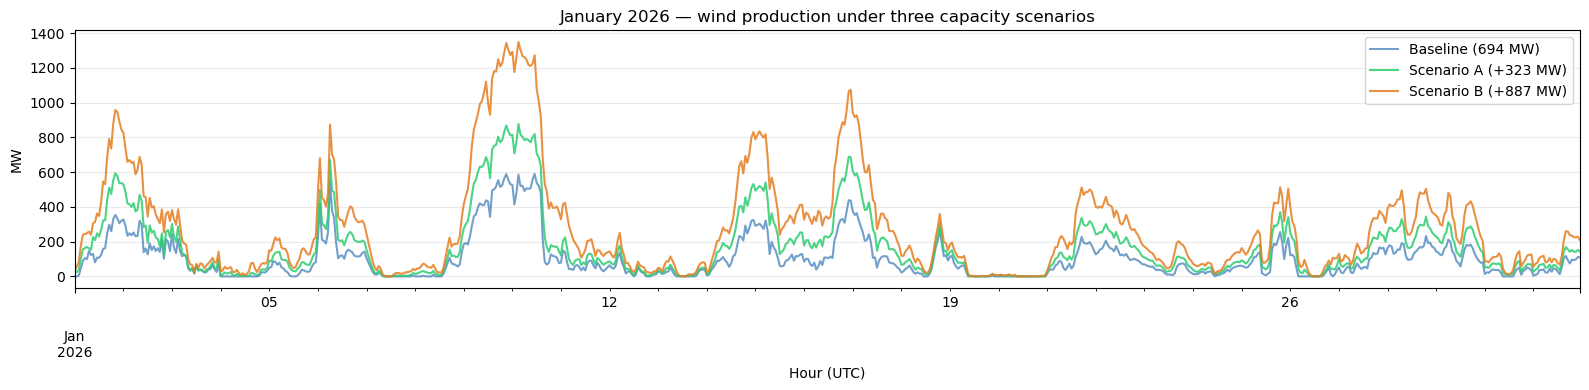

In [52]:
idx = baseline_mw.index

scenarios = pd.DataFrame({
    "wind_mwh_baseline": baseline_mw,
    "wind_mwh_scenA":    baseline_mw + new_A_mw.reindex(idx).fillna(0),
    "wind_mwh_scenB":    baseline_mw + new_A_mw.reindex(idx).fillna(0) + new_B_extra_mw.reindex(idx).fillna(0),
}, index=idx)

# Validate
assert len(scenarios) == 744, f"Expected 744 hours, got {len(scenarios)}"
assert scenarios.isna().sum().sum() == 0, f"NaNs found: {scenarios.isna().sum()}"
assert (scenarios["wind_mwh_scenA"] >= scenarios["wind_mwh_baseline"]).all(), \
    "Scenario A below baseline at some hours"
assert (scenarios["wind_mwh_scenB"] >= scenarios["wind_mwh_scenA"]).all(), \
    "Scenario B below Scenario A at some hours"

print("All validation checks passed.")
print()
print(scenarios.describe().round(1))

fig, ax = plt.subplots(figsize=(16, 4))
scenarios.plot(ax=ax, alpha=0.85,
               color=["#5a8fc2", "#2ecc71", "#e67e22"],
               title="January 2026 — wind production under three capacity scenarios")
ax.set_ylabel("MW")
ax.set_xlabel("Hour (UTC)")
ax.grid(True, alpha=0.25)
ax.legend(["Baseline (694 MW)", "Scenario A (+323 MW)", "Scenario B (+887 MW)"])
plt.tight_layout()
plt.show()

## Save

`wind_production_scenarios.csv` is loaded in `Supply.py` and passed as `wind_series` to `run_scenario()` for scenarios S3 and S4:

```python
scenarios = pd.read_csv("../data/wind_production_scenarios.csv", index_col=0, parse_dates=True)

p50_s3, p10_s3, p90_s3 = run_scenario(
    "S3: Isolated + Established plans (+323 MW)",
    isolate=True,
    wind_series=scenarios["wind_mwh_scenA"].values
)
```

The `wind_series` array replaces the flat `extra_wind_mw=500` placeholder, giving the GNN hour-by-hour realistic wind input for the test period instead of a constant offset.

In [53]:
out_path = "../data/wind_production_scenarios.csv"
scenarios.to_csv(out_path)
print(f"Saved: {out_path}")
print(f"Shape: {scenarios.shape}  ({scenarios.shape[0]} hours × {scenarios.shape[1]} scenarios)")
print()
print(scenarios.head(10).round(1))

Saved: ../data/wind_production_scenarios.csv
Shape: (744, 3)  (744 hours × 3 scenarios)

                           wind_mwh_baseline  wind_mwh_scenA  wind_mwh_scenB
timestamp                                                                   
2026-01-01 00:00:00+00:00                0.0            17.3            36.3
2026-01-01 01:00:00+00:00                0.0            25.7            55.0
2026-01-01 02:00:00+00:00                4.7            39.3            84.3
2026-01-01 03:00:00+00:00               48.2           101.3           177.8
2026-01-01 04:00:00+00:00               88.0           155.4           239.6
2026-01-01 05:00:00+00:00              105.6           163.3           244.4
2026-01-01 06:00:00+00:00               98.9           169.1           248.2
2026-01-01 07:00:00+00:00              146.6           161.5           257.6
2026-01-01 08:00:00+00:00              123.5           153.0           239.7
2026-01-01 09:00:00+00:00              129.4           226.6    